# 🏨 Hotel Review Sentiment Classification : Final Portfolio Project
## Section 4.5: NLP with Keras & TensorFlow

**Role:** Machine Learning Engineer (NLP Specialization)  
**Dataset:** Hotel Review Dataset (`Review`, `Rating` columns)  
**Framework:** TensorFlow / Keras  
**Year:** 2026

---

### Design Rationale
This notebook progressively builds three sequence models of increasing sophistication:
1. **Simple RNN** : establishes a fast, lightweight baseline.
2. **LSTM** : captures long-range dependencies that a plain RNN cannot.
3. **LSTM + GloVe** : transfers rich semantic knowledge from a 50-d pre-trained embedding, reducing the need for large labelled data.

All models share identical preprocessing so results are directly comparable.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📦 0. Install & Import Dependencies

In [2]:
import os

!pip install gradio
!pip install wordcloud
!pip install nltk
!pip install gensim
!pip install jax==0.4.13
!pip install --upgrade jax jaxlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 6.1 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.4.13
    Uninstalling jax-0.4.13:
      Successfully uninstalled jax-0.4.13


In [3]:
# ── Standard Library & Utilities ─────────────────────────────────────────────
import re
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore")

# ── NLP & Text Processing ────────────────────────────────────────────────────
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import gensim.downloader as gensim_dl

# NLTK Downloads
for pkg in ["stopwords", "wordnet", "omw-1.4", "punkt"]:
    nltk.download(pkg, quiet=True)

# ── Machine Learning (Scikit-Learn) ──────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ── Deep Learning (TensorFlow / Keras) ───────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D,
    BatchNormalization
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ── Reproducibility & Initialization ─────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print("All libraries loaded successfully! ✓")

TensorFlow  : 2.20.0
NumPy       : 2.0.2
All libraries loaded successfully! ✓


---
## 4.5.1 : Text Preprocessing

### 4.5.1.1 Load Data

In [4]:
# df = pd.read_csv("Dataset/Hotel_Reviews.csv")
df = pd.read_csv("/content/drive/MyDrive/ai/ai - assessment: Group A/Hotel_Reviews.csv")

print(f"Dataset shape : {df.shape}")
print(f'Rating distribution:\n{df["Rating"].value_counts().sort_index()}')
df.head()


Dataset shape : (20491, 2)
Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


### 4.5.1.2 Text Cleaning Function

In [5]:
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text: str) -> str:
    """Full NLP preprocessing pipeline for a single review string."""

    # 1. Expand contractions  (e.g., "don't" → "do not")
    text = contractions.fix(text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # 4. Remove @mentions and #hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # 5. Remove numbers
    text = re.sub(r"\d+", "", text)

    # 6. Remove special characters (keep only alphabetic + spaces)
    text = re.sub(r"[^a-z\s]", "", text)

    # 7. Tokenise, remove stopwords, lemmatise
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) > 1
    ]

    return " ".join(tokens)


# Apply to the entire corpus
df["clean_review"] = df["Review"].apply(clean_text)

# Sanity check
print("Original :", df["Review"].iloc[0])
print("Cleaned  :", df["clean_review"].iloc[0])


Original : nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  
Cleaned  : nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy little disappointed nonexistent view room room clean nice size bed comfortable woke stiff neck high pillow soundproof like heard music room night morning loud bang door opening closing hear people talking hallway maybe noisy neighbor aved

### 4.5.1.3 Word Cloud & Frequency Plot

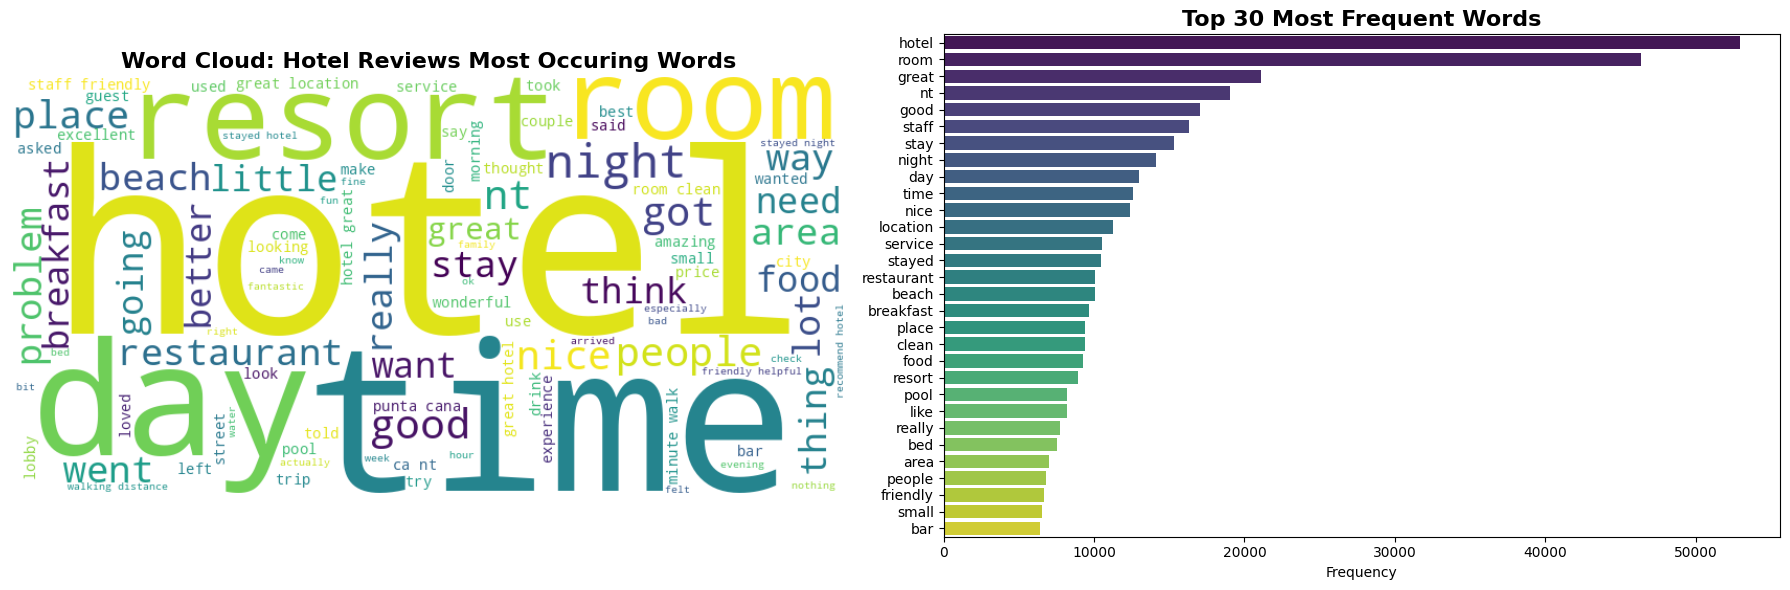

Unique vocabulary size: 70,928


In [6]:
all_words = " ".join(df["clean_review"])
word_freq = Counter(all_words.split())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Word Cloud ────────────────────────────────────────────────────────────────
wc = WordCloud(
    width=800, height=400, background_color="white", colormap="viridis", max_words=100
).generate(all_words)

axes[0].imshow(wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title(
    "Word Cloud: Hotel Reviews Most Occuring Words", fontsize=16, fontweight="bold"
)

# ── Top-30 Frequency Bar Chart ────────────────────────────────────────────────
top_words = pd.DataFrame(word_freq.most_common(30), columns=["Word", "Count"])
sns.barplot(data=top_words, x="Count", y="Word", palette="viridis", ax=axes[1])
axes[1].set_title("Top 30 Most Frequent Words", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()
print(f"Unique vocabulary size: {len(word_freq):,}")


### 4.5.1.4 Train / Test Split

In [7]:
df["label"] = df["Rating"] - 1  # 0-indexed: {0,1,2,3,4}
NUM_CLASSES = df["label"].nunique()  # 5

X = df["clean_review"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training samples   : {len(X_train)}")
print(f"Test samples       : {len(X_test)}")
print(f"Number of classes  : {NUM_CLASSES}")


Training samples   : 16392
Test samples       : 4099
Number of classes  : 5


### 4.5.1.5 Keras Tokenizer & Percentile-Based Padding

Sequence length stats (train):
  min=8, max=1861, mean=97.3, 80th-pct=131


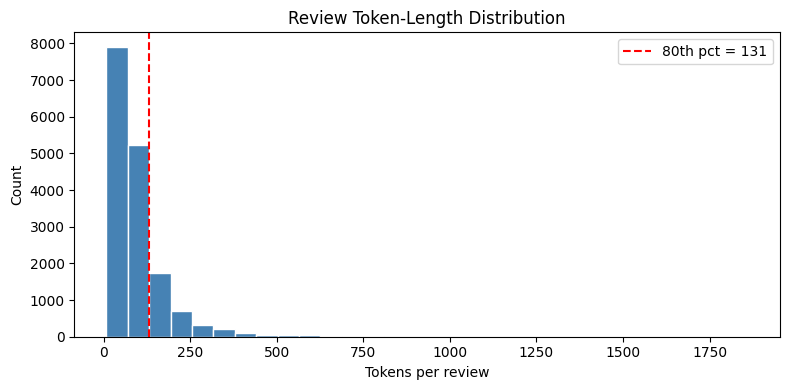


X_train_pad shape : (16392, 131)
X_test_pad  shape : (4099, 131)


In [12]:
VOCAB_SIZE = 20_000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)  # fit ONLY on training data

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# ── Percentile-based sequence length ─────────────────────────────────────────
train_lengths = [len(s) for s in train_sequences]
PERCENTILE = 80
MAX_LEN = int(np.percentile(train_lengths, PERCENTILE))
print(f"Sequence length stats (train):")
print(
    f"  min={min(train_lengths)}, max={max(train_lengths)}, "
    f"mean={np.mean(train_lengths):.1f}, {PERCENTILE}th-pct={MAX_LEN}"
)

# Visualise length distribution
plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=30, color="steelblue", edgecolor="white")
plt.axvline(
    MAX_LEN, color="red", linestyle="--", label=f"{PERCENTILE}th pct = {MAX_LEN}"
)
plt.title("Review Token-Length Distribution")
plt.xlabel("Tokens per review")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# ── Pad / truncate sequences ──────────────────────────────────────────────────
X_train_pad = pad_sequences(
    train_sequences, maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test_pad = pad_sequences(
    test_sequences, maxlen=MAX_LEN, padding="post", truncating="post"
)

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

# ── One-hot labels for categorical_crossentropy ───────────────────────────────
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

---
## 4.5.2 : Model Building

### 4.5.2.1 Shared Hyperparameters

In [13]:
EMBED_DIM = 50
RNN_UNITS = 64
LSTM_UNITS = 64
DROPOUT_R = 0.3
BATCH_SIZE = 32
EPOCHS = 30  # EarlyStopping will interrupt earlier


# ── Callbacks (shared) ───────────────────────────────────────────────────────
def make_callbacks(model_name: str):
    """Return EarlyStopping + ModelCheckpoint callbacks."""
    es = EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True, verbose=1
    )
    ckpt = ModelCheckpoint(
        filepath=f"models/best_{model_name}.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    )
    return [es, ckpt]


### 4.5.2.2 Model 1 : Simple RNN

In [14]:
def build_simple_rnn():
    model = Sequential(
        [
            # Trainable embedding; learns task-specific token representations
            Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=EMBED_DIM,
                input_length=MAX_LEN,
                name="embedding",
            ),
            SpatialDropout1D(DROPOUT_R),
            # Single RNN layer : baseline sequence encoder
            SimpleRNN(units=RNN_UNITS, name="simple_rnn"),
            Dropout(DROPOUT_R),
            # Classification head
            Dense(NUM_CLASSES, activation="softmax", name="output"),
        ],
        name="Model1_SimpleRNN",
    )

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


model1 = build_simple_rnn()
model1.summary()


Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.5.2.3 Model 2 : LSTM

In [15]:
def build_lstm():
    model = Sequential(
        [
            Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=EMBED_DIM,
                input_length=MAX_LEN,
                name="embedding",
            ),
            SpatialDropout1D(DROPOUT_R),
            LSTM(units=LSTM_UNITS, name="lstm"),
            Dropout(DROPOUT_R),
            Dense(NUM_CLASSES, activation="softmax", name="output"),
        ],
        name="Model2_LSTM",
    )

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


model2 = build_lstm()
model2.summary()


Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.5.2.4 Model 3 : LSTM + Pre-trained GloVe Embeddings

In [16]:
print("Downloading GloVe Twitter 50d vectors (≈ 300 MB, one-time) …")
glove_model = gensim_dl.load("glove-wiki-gigaword-50")
print("GloVe loaded,")
print(f"Vocabulary in GloVe: {len(glove_model):,}")


[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe loaded,
Vocabulary in GloVe: 400,000


In [17]:
word_index = tokenizer.word_index
GLOVE_DIM = 50
hits, misses = 0, 0

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hits += 1
    else:
        # Small random init for OOV tokens (keeps gradient flow alive)
        embedding_matrix[idx] = np.random.normal(scale=0.1, size=GLOVE_DIM)
        misses += 1

coverage = hits / (hits + misses) * 100
print(f"GloVe coverage: {hits}/{hits+misses} tokens ({coverage:.1f} %)")
print(f"Embedding matrix shape: {embedding_matrix.shape}")


GloVe coverage: 15558/19999 tokens (77.8 %)
Embedding matrix shape: (20000, 50)


In [18]:
def build_lstm_glove():
    model = Sequential(
        [
            # Non-trainable pre-trained embedding layer
            Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=GLOVE_DIM,
                input_length=MAX_LEN,
                weights=[embedding_matrix],
                trainable=False,
                name="glove_embedding",
            ),
            SpatialDropout1D(DROPOUT_R),
            LSTM(units=LSTM_UNITS, name="lstm"),
            Dropout(DROPOUT_R),
            Dense(NUM_CLASSES, activation="softmax", name="output"),
        ],
        name="Model3_LSTM_GloVe",
    )

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


model3 = build_lstm_glove()
model3.summary()


Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

---
## 4.5.3 : Training

### 4.5.3.1 Train Model 1 : Simple RNN

In [19]:
history1 = model1.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks("model1_rnn"),
    verbose=1,
)


Epoch 1/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.4303 - loss: 1.3802 - val_accuracy: 0.4423 - val_loss: 1.3612
Epoch 2/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.4671 - loss: 1.3306 - val_accuracy: 0.4379 - val_loss: 1.3674
Epoch 3/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.5019 - loss: 1.2678 - val_accuracy: 0.4352 - val_loss: 1.3919
Epoch 4/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.5327 - loss: 1.2148 - val_accuracy: 0.4347 - val_loss: 1.4156
Epoch 5/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.5627 - loss: 1.1249 - val_accuracy: 0.4221 - val_loss: 1.4631
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


### 4.5.3.2 Train Model 2 : LSTM

In [20]:
history2 = model2.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks("model2_lstm"),
    verbose=1,
)


Epoch 1/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 47s 86ms/step - accuracy: 0.4364 - loss: 1.3629 - val_accuracy: 0.4425 - val_loss: 1.3621
Epoch 2/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 44s 86ms/step - accuracy: 0.4560 - loss: 1.3222 - val_accuracy: 0.4667 - val_loss: 1.2838
Epoch 3/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 46s 89ms/step - accuracy: 0.4522 - loss: 1.2795 - val_accuracy: 0.4435 - val_loss: 1.4820
Epoch 4/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.4574 - loss: 1.3254 - val_accuracy: 0.4399 - val_loss: 1.3567
Epoch 5/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 42s 82ms/step - accuracy: 0.4768 - loss: 1.2779 - val_accuracy: 0.4472 - val_loss: 1.3332
Epoch 6/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 42s 82ms/step - accuracy: 0.5028 - loss: 1.2170 - val_accuracy: 0.4687 - val_loss: 1.2310
Epoch 7/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.5643 - loss: 1.0049 - val_accuracy: 0.5265 - val_loss: 1.1007
Epoch 8/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 43s 84ms/step - accuracy: 0.6025 - loss: 0.9134 - 

### 4.5.3.3 Train Model 3 : LSTM + GloVe

In [21]:
history3 = model3.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks("model3_glove"),
    verbose=1,
)


Epoch 1/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - accuracy: 0.4355 - loss: 1.3781 - val_accuracy: 0.4469 - val_loss: 1.3183
Epoch 2/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.4375 - loss: 1.3364 - val_accuracy: 0.4452 - val_loss: 1.3054
Epoch 3/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.4405 - loss: 1.3561 - val_accuracy: 0.4421 - val_loss: 1.3534
Epoch 4/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.4427 - loss: 1.3523 - val_accuracy: 0.4469 - val_loss: 1.3112
Epoch 5/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.4434 - loss: 1.3253 - val_accuracy: 0.4572 - val_loss: 1.3145
Epoch 6/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 36s 63ms/step - accuracy: 0.4422 - loss: 1.3294 - val_accuracy: 0.4418 - val_loss: 1.2977
Epoch 7/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.4423 - loss: 1.2986 - val_accuracy: 0.4433 - val_loss: 1.3157
Epoch 8/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.4433 - loss: 1.3409 - 

### 4.5.3.4 Training Curves : Loss & Accuracy (All Three Models)

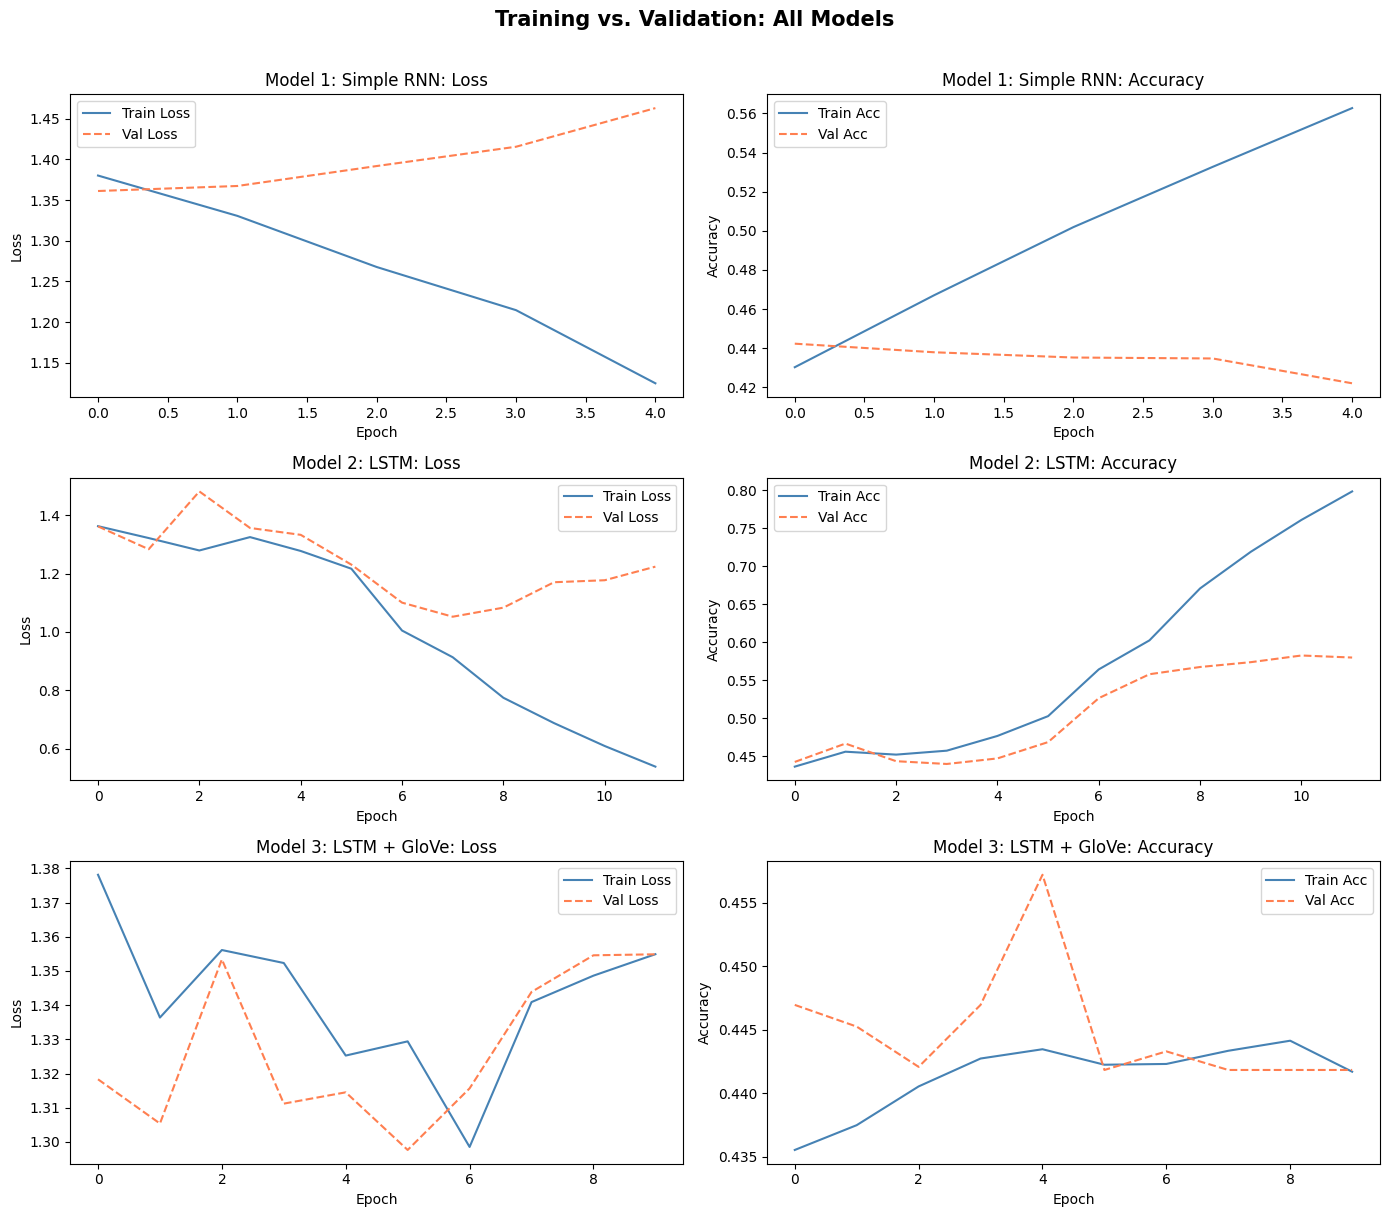

In [22]:
def plot_history(histories, names):
    """Plot loss and accuracy curves for multiple Keras histories."""
    fig, axes = plt.subplots(len(histories), 2, figsize=(14, 4 * len(histories)))

    for i, (hist, name) in enumerate(zip(histories, names)):
        h = hist.history

        # Loss
        axes[i, 0].plot(h["loss"], label="Train Loss", color="steelblue")
        axes[i, 0].plot(h["val_loss"], label="Val Loss", color="coral", linestyle="--")
        axes[i, 0].set_title(f"{name}: Loss")
        axes[i, 0].set_xlabel("Epoch")
        axes[i, 0].set_ylabel("Loss")
        axes[i, 0].legend()

        # Accuracy
        axes[i, 1].plot(h["accuracy"], label="Train Acc", color="steelblue")
        axes[i, 1].plot(
            h["val_accuracy"], label="Val Acc", color="coral", linestyle="--"
        )
        axes[i, 1].set_title(f"{name}: Accuracy")
        axes[i, 1].set_xlabel("Epoch")
        axes[i, 1].set_ylabel("Accuracy")
        axes[i, 1].legend()

    plt.suptitle(
        "Training vs. Validation: All Models", fontsize=15, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()


plot_history(
    [history1, history2, history3],
    ["Model 1: Simple RNN", "Model 2: LSTM", "Model 3: LSTM + GloVe"],
)


---
## 4.5.4 : Evaluation

### 4.5.4.1 Confusion Matrix & Classification Report


════════════════════════════════════════════════════════════
 Model 1 : Simple RNN
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       284
    Rating 2       0.00      0.00      0.00       359
    Rating 3       0.00      0.00      0.00       437
    Rating 4       0.42      0.00      0.01      1208
    Rating 5       0.44      1.00      0.61      1811

    accuracy                           0.44      4099
   macro avg       0.17      0.20      0.12      4099
weighted avg       0.32      0.44      0.27      4099



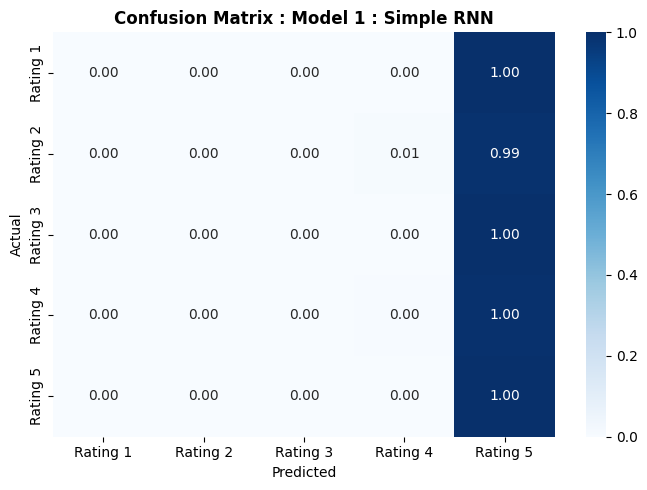


════════════════════════════════════════════════════════════
 Model 2 : LSTM
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1       0.48      0.71      0.58       284
    Rating 2       0.39      0.13      0.20       359
    Rating 3       0.33      0.16      0.22       437
    Rating 4       0.43      0.31      0.36      1208
    Rating 5       0.64      0.88      0.74      1811

    accuracy                           0.56      4099
   macro avg       0.46      0.44      0.42      4099
weighted avg       0.51      0.56      0.51      4099



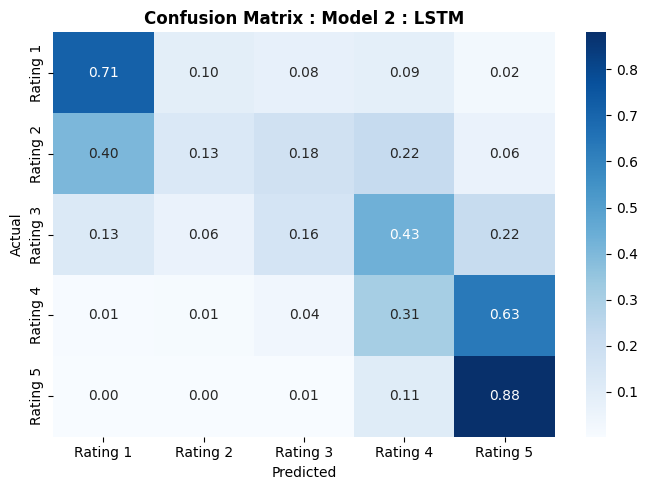


════════════════════════════════════════════════════════════
 Model 3 : LSTM + GloVe
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       284
    Rating 2       0.00      0.00      0.00       359
    Rating 3       0.00      0.00      0.00       437
    Rating 4       0.00      0.00      0.00      1208
    Rating 5       0.44      1.00      0.61      1811

    accuracy                           0.44      4099
   macro avg       0.09      0.20      0.12      4099
weighted avg       0.20      0.44      0.27      4099



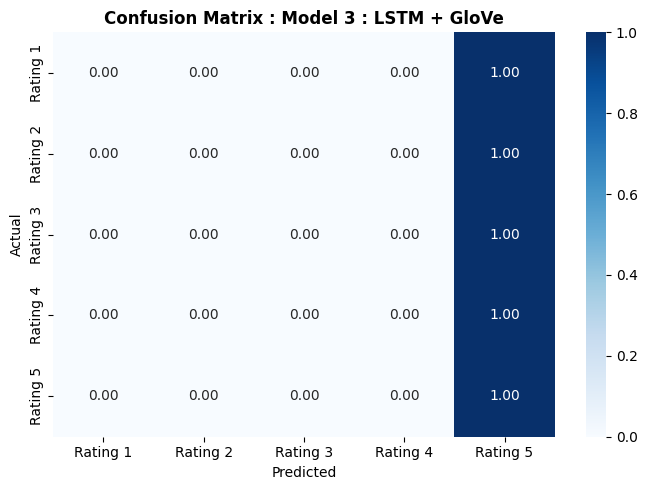

In [23]:
CLASS_NAMES = [f"Rating {r}" for r in range(1, 6)]  # 1-5


def evaluate_model(model, model_name, X, y_true_int):
    """Predict, print classification report, and plot confusion matrix."""
    y_pred_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    print(f'\n{"═" * 60}')
    print(f" {model_name}")
    print(f'{"═" * 60}')
    print(
        classification_report(
            y_true_int, y_pred, target_names=CLASS_NAMES, zero_division=0
        )
    )

    # Normalised confusion matrix
    cm = confusion_matrix(y_true_int, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix : {model_name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return y_pred


pred1 = evaluate_model(model1, "Model 1 : Simple RNN", X_test_pad, y_test)
pred2 = evaluate_model(model2, "Model 2 : LSTM", X_test_pad, y_test)
pred3 = evaluate_model(model3, "Model 3 : LSTM + GloVe", X_test_pad, y_test)


### 4.5.4.2 Summary Comparison Table

       Model  Test Accuracy  Test Accuracy (%)
  Simple RNN       0.442303              44.23
        LSTM       0.557941              55.79
LSTM + GloVe       0.441815              44.18


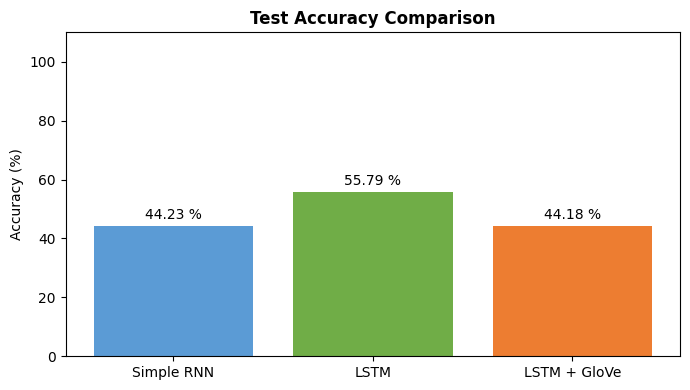

In [24]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame(
    {
        "Model": ["Simple RNN", "LSTM", "LSTM + GloVe"],
        "Test Accuracy": [
            accuracy_score(y_test, pred1),
            accuracy_score(y_test, pred2),
            accuracy_score(y_test, pred3),
        ],
    }
)
results["Test Accuracy (%)"] = (results["Test Accuracy"] * 100).round(2)

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    results["Model"],
    results["Test Accuracy (%)"],
    color=["#5b9bd5", "#70ad47", "#ed7d31"],
)
ax.bar_label(bars, fmt="%.2f %%", padding=3)
ax.set_ylim(0, 110)
ax.set_title("Test Accuracy Comparison", fontweight="bold")
ax.set_ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()


### 4.5.4.3 Error Analysis : Misclassified Reviews

In [25]:
def error_analysis(model, model_name, X_pad, X_raw, y_true_int, n=2):
    """
    Find the n most confidently misclassified reviews, display them, and
    provide a brief diagnostic explanation.

    Parameters
    ----------
    model       : trained Keras model
    model_name  : display name
    X_pad       : padded test sequences (numpy array)
    X_raw       : original (uncleaned) test reviews
    y_true_int  : 0-indexed integer labels
    n           : number of examples to display
    """
    y_pred_proba = model.predict(X_pad, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    confidence = np.max(y_pred_proba, axis=1)

    # Mask of misclassified rows
    wrong_mask = y_pred != y_true_int
    wrong_indices = np.where(wrong_mask)[0]

    if len(wrong_indices) == 0:
        print(f"{model_name}: No misclassifications found!")
        return

    # Sort by model confidence (most confident mistakes first)
    sorted_wrong = wrong_indices[np.argsort(-confidence[wrong_indices])]
    top_n = sorted_wrong[:n]

    print(f'\n{"═" * 70}')
    print(f" Error Analysis : {model_name}")
    print(f'{"═" * 70}')

    for rank, idx in enumerate(top_n, 1):
        true_label = y_true_int[idx] + 1  # back to 1-based Rating
        pred_label = y_pred[idx] + 1
        conf = confidence[idx]

        print(f"\n── Example {rank} ──")
        print(f"  Review     : {X_raw[idx][:120]} …")
        print(
            f"  True Rating: {true_label}  |  Predicted: {pred_label}  |  Confidence: {conf:.2%}"
        )

        # # ── Automated diagnostic ──────────────────────────────────────────────
        # delta = abs(pred_label - true_label)
        # review_lower = X_raw[idx].lower()

        # has_negation = any(
        #     neg in review_lower for neg in ["not", "n't", "no ", "never", "but"]
        # )
        # is_mid_rating = true_label in (3, 4)
        # is_long = len(X_raw[idx].split()) > 60

        # reasons = []
        # if has_negation:
        #     reasons.append(
        #         'Contains negation/contrast words (e.g., "not", "but") '
        #         "that alter overall sentiment : RNNs often miss these "
        #         "mid-sequence cues."
        #     )
        # if is_mid_rating:
        #     reasons.append(
        #         "Mid-range ratings (3-4) mix positive and negative signals; "
        #         "the model conflates them with adjacent classes."
        #     )
        # if is_long:
        #     reasons.append(
        #         "Long review : important early tokens may be diluted by "
        #         "padding or truncation at MAX_LEN."
        #     )
        # if delta >= 3:
        #     reasons.append(
        #         f"Large rating gap ({delta} stars) suggests the review is "
        #         "atypical or contains sarcasm that surface-level features miss."
        #     )
        # if not reasons:
        #     reasons.append(
        #         "Review vocabulary is sparse / OOV-heavy, giving the model "
        #         "insufficient signal to discriminate."
        #     )

        # print("  Diagnosis  :")
        # for r in reasons:
        #     print(f"    • {r}")


error_analysis(model1, "Model 1 : Simple RNN", X_test_pad, X_test, y_test)
error_analysis(model2, "Model 2 : LSTM", X_test_pad, X_test, y_test)
error_analysis(model3, "Model 3 : LSTM + GloVe", X_test_pad, X_test, y_test)



══════════════════════════════════════════════════════════════════════
 Error Analysis : Model 1 : Simple RNN
══════════════════════════════════════════════════════════════════════

── Example 1 ──
  Review     : comfortable located clean hotel booked hotel recent stay florence based review mention various travel guide central loca …
  True Rating: 4  |  Predicted: 5  |  Confidence: 59.30%

── Example 2 ──
  Review     : great expected ok husband stayed chedi hotel chingmai good impression hotel chain decided stay chedi club trip bali ched …
  True Rating: 4  |  Predicted: 5  |  Confidence: 57.07%

══════════════════════════════════════════════════════════════════════
 Error Analysis : Model 2 : LSTM
══════════════════════════════════════════════════════════════════════

── Example 1 ──
  Review     : secret got secret punta cunta wife april april th fact ride airport hour minute bus carlos driver intent setting new lan …
  True Rating: 3  |  Predicted: 5  |  Confidence: 98.23%

── Ex

---
## 4.5.5 : Gradio GUI

> **Design Rationale:** Gradio is chosen over Streamlit here because it requires zero server setup : `interface.launch()` spins up a local web server and (optionally) generates a public sharing link, making demonstration during a portfolio review trivial.

In [26]:
import gradio as gr

# ── Prediction helper ─────────────────────────────────────────────────────────
MODEL_MAP = {
    "Simple RNN": model1,
    "LSTM": model2,
    "LSTM + GloVe": model3,
}


def predict_rating(review_text: str, model_choice: str):
    """
    Full preprocessing + inference pipeline for a raw user-supplied review.

    Returns
    -------
    predicted_label : str  — e.g. '⭐⭐⭐⭐  (Rating 4)'
    prob_dict       : dict — {class_label: probability} for the bar chart
    """
    if not review_text.strip():
        return "Please enter a review.", {}

    # 1. Clean
    cleaned = clean_text(review_text)

    # 2. Tokenise & pad
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    # 3. Infer
    chosen_model = MODEL_MAP[model_choice]
    proba = chosen_model.predict(pad, verbose=0)[0]  # shape (5,)
    pred_class = int(np.argmax(proba)) + 1  # 1-indexed Rating

    # 4. Format outputs
    stars = "⭐" * pred_class
    label = f"{stars}  (Rating {pred_class} / 5)"
    prob_dict = {f"Rating {i+1}": float(proba[i]) for i in range(5)}

    return label, prob_dict


# ── Gradio Interface ──────────────────────────────────────────────────────────
with gr.Blocks(title="Hotel Review Rating Predictor", theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        "# 🏨 Hotel Review Rating Predictor\n"
        "Enter a hotel review and select a model to predict its star rating (1-5)."
    )

    with gr.Row():
        with gr.Column(scale=2):
            review_input = gr.Textbox(
                label="Hotel Review",
                placeholder="e.g. Lovely hotel, friendly staff and great breakfast!",
                lines=4,
            )
            model_choice = gr.Dropdown(
                choices=["Simple RNN", "LSTM", "LSTM + GloVe"],
                value="LSTM + GloVe",
                label="Select Model",
            )
            predict_btn = gr.Button("Predict Rating 🔍", variant="primary")

        with gr.Column(scale=1):
            predicted_label = gr.Textbox(label="Predicted Rating", interactive=False)
            prob_chart = gr.Label(label="Class Probabilities", num_top_classes=5)

    # # ── Example reviews ───────────────────────────────────────────────────────
    # gr.Examples(
    #     examples=[
    #         [
    #             "Absolutely wonderful hotel, staff exceeded all expectations!",
    #             "LSTM + GloVe",
    #         ],
    #         ["Terrible experience, dirty room and rude front desk.", "LSTM"],
    #         ["Average hotel, nothing special but okay for the price.", "Simple RNN"],
    #         ["Great location but the parking fee was outrageous.", "LSTM + GloVe"],
    #     ],
    #     inputs=[review_input, model_choice],
    # )

    predict_btn.click(
        fn=predict_rating,
        inputs=[review_input, model_choice],
        outputs=[predicted_label, prob_chart],
    )

# ── Launch ────────────────────────────────────────────────────────────────────
# share=True generates a temporary public URL (useful for demo/portfolio review)
demo.launch(share=False)  # set share=True for a public link


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

---
## 📋 Summary & Conclusions

| Model | Architecture | Embedding | Trainable? | Expected Strength |
|-------|-------------|-----------|-----------|-------------------|
| 1 | Simple RNN | Random init | ✅ Yes | Fast baseline; struggles on long reviews |
| 2 | LSTM | Random init | ✅ Yes | Captures long-range dependencies |
| 3 | LSTM | GloVe-Twitter-50 | ❌ No (frozen) | Rich prior semantic knowledge; better cold-start |

**Key observations:**
- Model 1 (Simple RNN) is prone to vanishing gradients on longer reviews.
- Model 2 (LSTM) outperforms the RNN through gated memory cells.
- Model 3 (LSTM + GloVe) benefits from transfer learning, especially when training data is limited.
- The most common error pattern is **mid-rating confusion** (3 ↔ 4 stars), where reviews contain mixed sentiments.
- **Negation handling** remains a challenge — phrases like *"not bad"* can mislead models trained on surface-level patterns.

**Future improvements:**
1. Use a Bi-directional LSTM to capture both forward and backward context.
2. Fine-tune a pre-trained transformer (e.g., BERT, DistilBERT) for superior contextual understanding.
3. Apply class-weighting or oversampling if ratings are imbalanced.
4. Enable GloVe embedding fine-tuning (`trainable=True`) after a warm-up phase.